<a href="https://colab.research.google.com/github/krishn12323/aiml_lab/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
from sklearn.datasets import load_breast_cancer

# Load Breast Cancer Wisconsin dataset
data = load_breast_cancer()

# Features
X = data.data

# Original target
y_original = data.target

# Original:
# 0 = malignant
# 1 = benign

# Convert to:
# 1 = malignant
# 0 = benign
y = 1 - y_original

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

print("Target Names:")
print("0 = Benign")
print("1 = Malignant")

print("\nNumber of Benign cases:", sum(y == 0))
print("Number of Malignant cases:", sum(y == 1))

Dataset Shape: (569, 30)
Target Shape: (569,)
Target Names:
0 = Benign
1 = Malignant

Number of Benign cases: 357
Number of Malignant cases: 212


In [44]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Check for missing values
print("Number of missing values:", np.isnan(X).sum())


# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Create StandardScaler
scaler = StandardScaler()

# Fit only on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Number of missing values: 0
Training data shape: (398, 30)
Testing data shape: (171, 30)
Feature scaling completed.


In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree Training Completed")

# Predict training data
dt_train_pred = dt_model.predict(X_train)

# Calculate training accuracy
dt_train_accuracy = accuracy_score(y_train, dt_train_pred)

print("Decision Tree Training Accuracy:", dt_train_accuracy)

Decision Tree Training Completed
Decision Tree Training Accuracy: 1.0


In [46]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=10000)

# Train Logistic Regression
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression Training Completed")

# Predict training data
lr_train_pred = lr_model.predict(X_train_scaled)

# Training accuracy
lr_train_accuracy = accuracy_score(y_train, lr_train_pred)

print("Logistic Regression Training Accuracy:", lr_train_accuracy)

Logistic Regression Training Completed
Logistic Regression Training Accuracy: 0.9874371859296482



Decision Tree Results
--------------------
Accuracy : 0.9005847953216374
Precision: 0.8852459016393442
Recall   : 0.84375
F1 Score : 0.864

Decision Tree Confusion Matrix:
[[100   7]
 [ 10  54]]


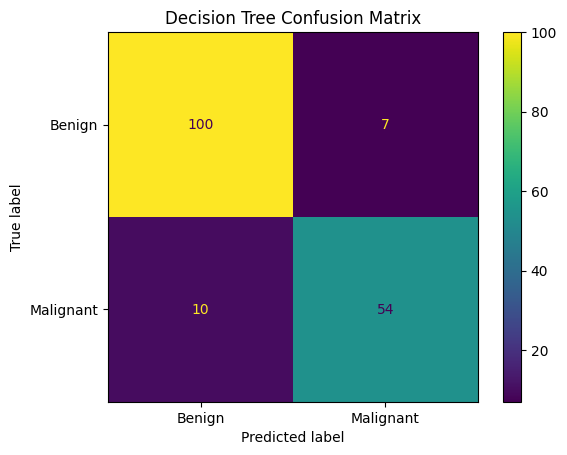

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# =========================
# DECISION TREE TESTING
# =========================

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("\nDecision Tree Results")
print("--------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

# Decision Tree Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_pred)

print("\nDecision Tree Confusion Matrix:")
print(dt_cm)

dt_display = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["Benign", "Malignant"]
)

dt_display.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()


Logistic Regression Results
---------------------------
Accuracy : 0.9707602339181286
Precision: 0.9836065573770492
Recall   : 0.9375
F1 Score : 0.96

Logistic Regression Confusion Matrix:
[[106   1]
 [  4  60]]


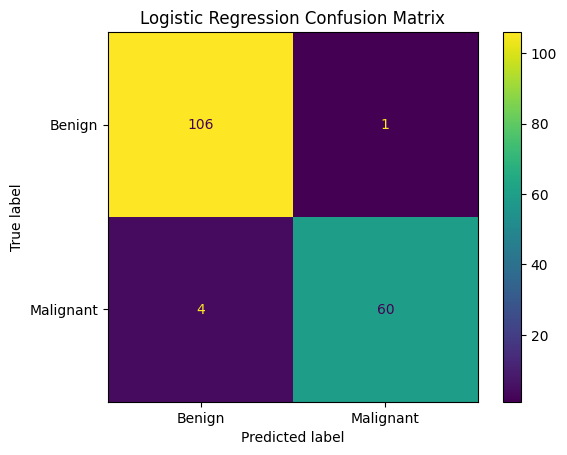

In [48]:
# =========================
# LOGISTIC REGRESSION TESTING
# =========================

lr_pred = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("\nLogistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

# Logistic Regression Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_pred)

print("\nLogistic Regression Confusion Matrix:")
print(lr_cm)

lr_display = ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["Benign", "Malignant"]
)

lr_display.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [49]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Decision Tree", "Logistic Regression"],
    "Accuracy": [dt_accuracy, lr_accuracy],
    "Precision": [dt_precision, lr_precision],
    "Recall": [dt_recall, lr_recall],
    "F1 Score": [dt_f1, lr_f1]
})

print("\nModel Comparison")
print("================")
print(results)


Model Comparison
                 Model  Accuracy  Precision   Recall  F1 Score
0        Decision Tree  0.900585   0.885246  0.84375     0.864
1  Logistic Regression  0.970760   0.983607  0.93750     0.960
